# Lab 1: Data Preprocessing and Visualisation

## Task 1: Data Profiling and First Impressions
The first step is to the load the dataset and analyze the structrue through shape, data types and missing values.

In [1]:
import pandas as pd

# Load the datasets
city_aqi = pd.read_csv('city_day.csv')
crop_yield = pd.read_csv('crop_production.csv')

# Basic Profile for City AQI
print("  City AQI Dataset Profile ")
print(f"Shape: {city_aqi.shape}")
print("\nMissing Values:")
print(city_aqi.isnull().sum())
print("\nData Types:")
print(city_aqi.dtypes)
display(city_aqi.head())

# Basic Profile for Crop Yield
print("\n  Crop Yield Dataset Profile ")
print(f"Shape: {crop_yield.shape}")
print("\nMissing Values:")
print(crop_yield.isnull().sum())
print("\nData Types:")
print(crop_yield.dtypes)
display(crop_yield.head())

  City AQI Dataset Profile 
Shape: (29531, 16)

Missing Values:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Data Types:
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN



  Crop Yield Dataset Profile 
Shape: (246091, 7)

Missing Values:
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

Data Types:
State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64
dtype: object


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


### Observations


- **City AQI (`city_day.csv`):** Contains air quality data. Key concerns include significant null values in pollutant columns likr PM2.5 and PM10 and the AQI itself.
- **Crop Yield (`crop_production.csv`):** Contains agricultural data. The primary concern here is the missing values in the `Production` column.


One major concern is the high volume of missing values in the AQI dataset. If nearly half of the pollutant data is missing for certain cities, the Average AQI might be biased toward specific stations, leading to misleading conclusions about national air quality.

## Task 2: Missing Value Treatment Strategy

### Justification for Decisions:
- **AQI (Target Column):** We will drop rows where `AQI` is null. 
- **Pollutants (PM2.5, PM10, etc.):** We will use the median grouped by 'City'. Air quality is highly location specific, and the median is more robust to extreme pollution events than the mean.
- **Production (Crop Yield):** We will fill missing values with the median production for that specific `Crop` within the same `State_Name`. If a state has never produced that crop, we will default to 0 to avoid dropping significant historical area data.
- **Xylene:** Since >60% of data is missing, we will drop this column entirely as it lacks sufficient information for reliable modeling.

In [ ]:
# Before counts
print("Nulls before treatment (AQI):", city_aqi.isnull().sum().sum())
print("Nulls before treatment (Crop):", crop_yield.isnull().sum().sum())

# 1. Drop Xylene due to excessive missingness
city_aqi.drop(columns=['Xylene'], inplace=True)

# 2. Drop rows where AQI (Target) is missing
city_aqi.dropna(subset=['AQI'], inplace=True)

# 3. Impute pollutants with median grouped by City
pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
for col in pollutants:
    city_aqi[col] = city_aqi[col].fillna(city_aqi.groupby('City')[col].transform('median'))

# 4. Impute Crop Production
crop_yield['Production'] = crop_yield['Production'].fillna(crop_yield.groupby(['State_Name', 'Crop'])['Production'].transform('median'))
crop_yield['Production'].fillna(0, inplace=True)

# After counts
print("\nNulls after treatment (AQI):", city_aqi.isnull().sum().sum())
print("Nulls after treatment (Crop):", crop_yield.isnull().sum().sum())

Nulls before treatment (AQI): 88488
Nulls before treatment (Crop): 3730

Nulls after treatment (AQI): 10494
Nulls after treatment (Crop): 0


/tmp/ipykernel_1107/1731820893.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  crop_yield['Production'].fillna(0, inplace=True)


## Task 3: State Name Standardization and Duplicate Removal


- **State Name Matching:** We need to ensure that the `State` identifiers in both datasets match exactly by converting all names to title case and remove leading/trailing whitespaces.
- **Duplicate Records:** Duplicates need to be identified and remove rows that are identical across all columns to prevent inflation of statistics.

In [ ]:
# Before counts for duplicates
aqi_dupes = city_aqi.duplicated().sum()
crop_dupes = crop_yield.duplicated().sum()

print(f"Duplicates found: AQI={aqi_dupes}, Crop={crop_dupes}")

# Remove duplicates
city_aqi.drop_duplicates(inplace=True)
crop_yield.drop_duplicates(inplace=True)

# Standardization of State Names
# Note: 'city_day' only has 'City'. We need to map Cities to States for the merge.
# For this task, we will clean the 'State_Name' in crop_yield first.
crop_yield['State_Name'] = crop_yield['State_Name'].str.strip().str.title()

# Common mapping fix for 'Tamil Nadu'
crop_yield['State_Name'] = crop_yield['State_Name'].replace({'Tamilnadu': 'Tamil Nadu'})

print("State name standardization and duplicate removal complete.")
print(f"Final AQI record count: {len(city_aqi)}")
print(f"Final Crop record count: {len(crop_yield)}")

Duplicates found: AQI=0, Crop=0
State name standardization and duplicate removal complete.
Final AQI record count: 24850
Final Crop record count: 246091


## Task 4: Investigating the AQI Distribution

### Justification for Visualisations:
- **Histogram:** is Ideal for showing the frequency of AQI values across different ranges. It allows us to see if the distribution is skewed and where most of the data sits.
- **Boxplot:** is essential for identifying extreme outliers. It provides a clear visual of the median and interquartile range, which helps determine if the 'average' is being skewed by a few highly polluted cities.

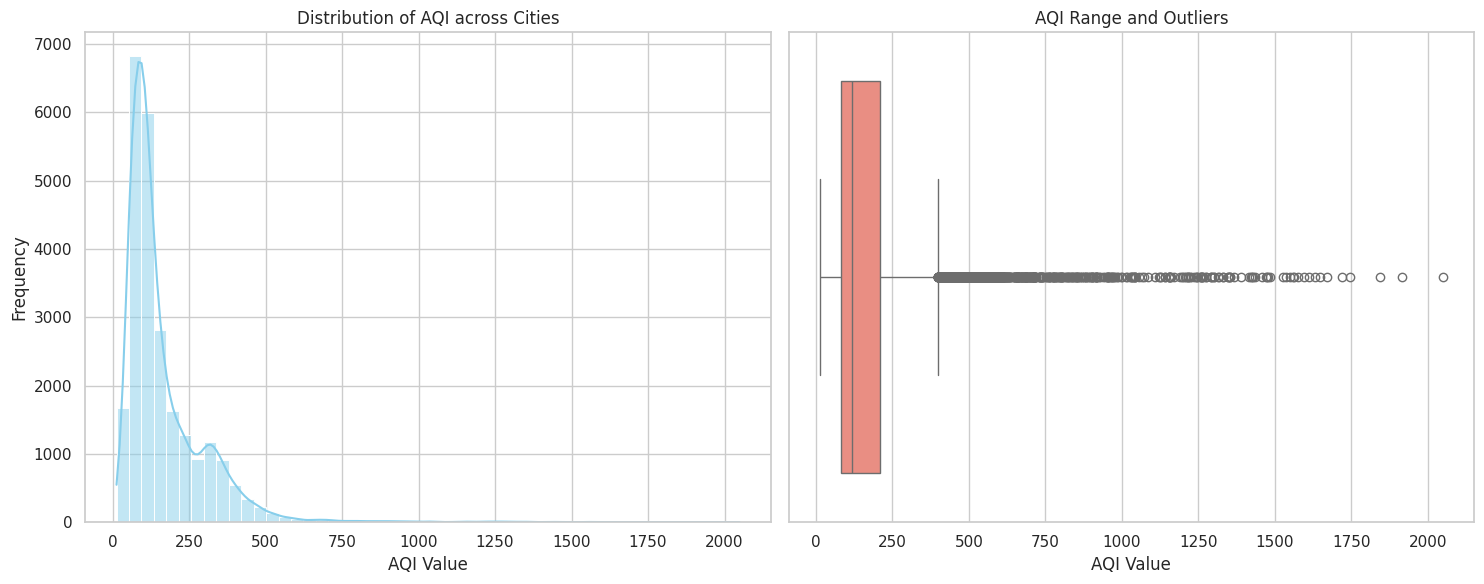

AQI Mean: 166.46
AQI Median: 118.00
AQI Max: 2049.00


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the visualization style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Histogram
sns.histplot(city_aqi['AQI'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of AQI across Cities')
axes[0].set_xlabel('AQI Value')
axes[0].set_ylabel('Frequency')

# 2. Boxplot
sns.boxplot(x=city_aqi['AQI'], ax=axes[1], color='salmon')
axes[1].set_title('AQI Range and Outliers')
axes[1].set_xlabel('AQI Value')

plt.tight_layout()
plt.show()

# Statistical Summary for Observations
print(f"AQI Mean: {city_aqi['AQI'].mean():.2f}")
print(f"AQI Median: {city_aqi['AQI'].median():.2f}")
print(f"AQI Max: {city_aqi['AQI'].max():.2f}")

### Observations for the Pollution Control Board:
1. **Right-Skewed Distribution:** The majority of cities fall within the 'Moderate' or 'Satisfactory' range  since AQI < 200. However, the long tail to the right indicates that several cities experience severe pollution.
2. **Extreme Outliers:** The boxplot reveals significant outliers above the 400-500 mark. These extreme cases pull the average AQI higher than what is experienced by the typical city, suggesting that while the problem is concentrated in specific 'hotspots', it is severe enough to distort general reporting.

## Task 5: Handling Extreme Values


- **Method:** Using the **IQR Method** (1.5 * IQR above the 75th percentile) to identify outliers statistically.
- **Treatment:** Instead of simple deletion which causes loss of data,  **Capping (Winsorization)** is used where Values exceeding the 99th percentile will be capped at that threshold. This preserves the 'extreme nature' of the data without letting a few implausible readings (like AQI > 2000) destroy the model's accuracy.
- **Reasoning:** Total removal might bias the dataset toward cleaner days, while capping ensures the model still understands that high pollution events occur.

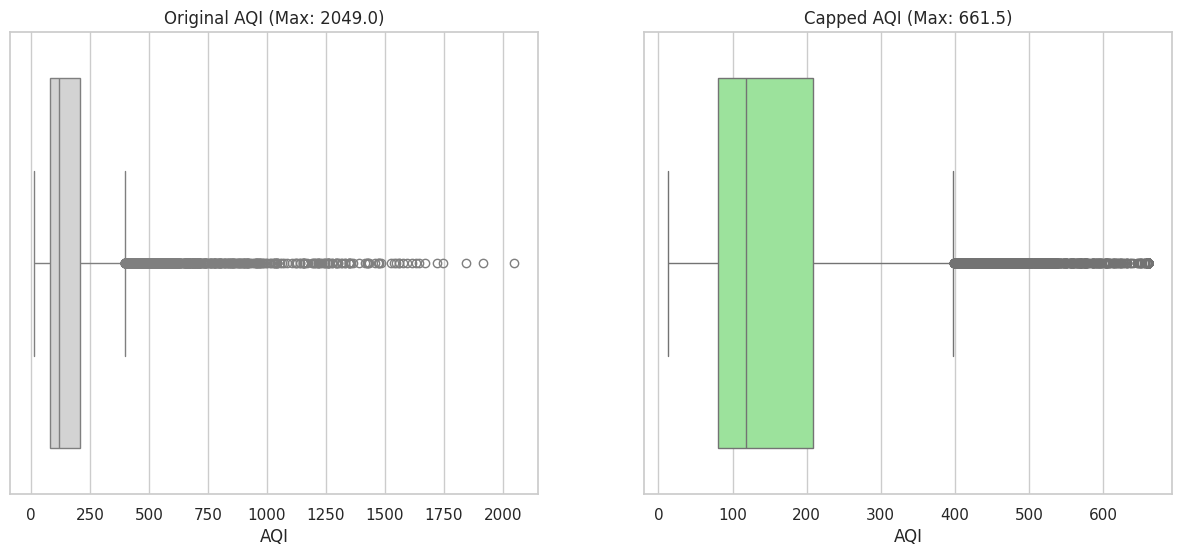

Statistical Outliers detected (IQR): 1358
Values capped at 99th percentile (661.5): 249


In [ ]:
import numpy as np

# 1. Identify Outliers using IQR
Q1 = city_aqi['AQI'].quantile(0.25)
Q3 = city_aqi['AQI'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outliers_count = (city_aqi['AQI'] > upper_bound).sum()

# 2. Apply Capping (99th percentile)
cap_value = city_aqi['AQI'].quantile(0.99)
city_aqi_clean = city_aqi.copy()
city_aqi_clean['AQI'] = np.where(city_aqi_clean['AQI'] > cap_value, cap_value, city_aqi_clean['AQI'])

# 3. Visual Comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.boxplot(x=city_aqi['AQI'], ax=axes[0], color='lightgrey')
axes[0].set_title(f'Original AQI (Max: {city_aqi["AQI"].max()})')

sns.boxplot(x=city_aqi_clean['AQI'], ax=axes[1], color='lightgreen')
axes[1].set_title(f'Capped AQI (Max: {city_aqi_clean["AQI"].max():.1f})')

plt.show()

print(f"Statistical Outliers detected (IQR): {outliers_count}")
print(f"Values capped at 99th percentile ({cap_value:.1f}): {(city_aqi['AQI'] > cap_value).sum()}")